<a href="https://colab.research.google.com/github/GabsCavalcant/Aplicacao-Utilizando-llm-Rn-etc/blob/main/RedeNeural.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [87]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [88]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [90]:
df = df.drop(columns= 'customerID')

In [91]:
df.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [92]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [93]:
df = pd.get_dummies(df, columns= ['MultipleLines','InternetService','Contract', 'PaymentMethod','MonthlyCharges'  ])

In [94]:
#transformando  em binario

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

colunasBinarias = [ 'gender','Partner', 'Dependents', 'PhoneService', 'OnlineSecurity','DeviceProtection','TechSupport',
                     'StreamingTV', 'StreamingMovies','PaperlessBilling','OnlineBackup',]

for col in colunasBinarias:
  df[col] = le.fit_transform(df[col])

In [95]:
df.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,MonthlyCharges_117.35,MonthlyCharges_117.45,MonthlyCharges_117.5,MonthlyCharges_117.6,MonthlyCharges_117.8,MonthlyCharges_118.2,MonthlyCharges_118.35,MonthlyCharges_118.6,MonthlyCharges_118.65,MonthlyCharges_118.75
0,0,0,1,0,1,0,0,2,0,0,...,False,False,False,False,False,False,False,False,False,False
1,1,0,0,0,34,1,2,0,2,0,...,False,False,False,False,False,False,False,False,False,False
2,1,0,0,0,2,1,2,2,0,0,...,False,False,False,False,False,False,False,False,False,False
3,1,0,0,0,45,0,2,0,2,2,...,False,False,False,False,False,False,False,False,False,False
4,0,0,0,0,2,1,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
5,0,0,0,0,8,1,0,0,2,0,...,False,False,False,False,False,False,False,False,False,False
6,1,0,0,1,22,1,0,2,0,0,...,False,False,False,False,False,False,False,False,False,False
7,0,0,0,0,10,0,2,0,0,0,...,False,False,False,False,False,False,False,False,False,False
8,0,0,1,0,28,1,0,0,2,2,...,False,False,False,False,False,False,False,False,False,False
9,1,0,0,1,62,1,2,2,0,0,...,False,False,False,False,False,False,False,False,False,False


In [96]:
x = df.drop('Churn', axis= 1)
y = df['Churn']

In [97]:
y

,Churn
0,No
1,No
2,Yes
3,No
4,Yes
...,...
7038,No
7039,No
7040,No
7041,Yes


In [98]:
#transformar todos os daods em 0/no 1/yes
df = df.replace({True: 1, False: 0})

y = df['Churn'].map({'Yes': 1, 'No' :0})

/tmp/ipykernel_303/697461600.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({True: 1, False: 0})


In [99]:
y

,Churn
0,0
1,0
2,1
3,0
4,1
...,...
7038,0
7039,0
7040,0
7041,1


In [100]:
#treino
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size= 0.2, random_state=42  )

In [101]:
#padronizando
from sklearn.preprocessing import StandardScaler

scale = StandardScaler()

x_train = scale.fit_transform(x_train)
x_test = scale.transform(x_test)

In [121]:
#Rede neural
import tensorflow as tf

modelo = tf.keras.Sequential([

    tf.keras.layers.Dense(16, activation= 'relu', input_shape= (x_train.shape[1],)),
    #adicao os Dropout para esligar 20% dos neuronios, pra não viciar.
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(16, activation= 'relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(8, activation = 'relu'),
    tf.keras.layers.Dense(1,activation= 'sigmoid'),
])

In [126]:

#estava tendo problema de modedo viciao, adicionei essa linha para quando começar aumnetar o loss, ele parar
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

historico = modelo.fit(
    x_train, y_train,
    epochs=50,
    validation_split=0.2,
    callbacks=[callback] # Isso vai impedir o overfitting!
)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8662 - loss: 0.2586 - val_accuracy: 0.7187 - val_loss: 1.0550
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8691 - loss: 0.2461 - val_accuracy: 0.7178 - val_loss: 1.1583
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8713 - loss: 0.2578 - val_accuracy: 0.7232 - val_loss: 1.1810
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8791 - loss: 0.2367 - val_accuracy: 0.7178 - val_loss: 1.2664


In [122]:
 #utilizano o treinnamento, com 20 epocas.
modelo.compile(optimizer= 'adam', loss= 'binary_crossentropy', metrics=['accuracy'])
modelo.fit(x_train,y_train, epochs= 20, batch_size=32, validation_split=0.2)

Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5354 - loss: 0.7552 - val_accuracy: 0.7480 - val_loss: 0.5287
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7042 - loss: 0.5812 - val_accuracy: 0.7533 - val_loss: 0.4894
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7258 - loss: 0.5300 - val_accuracy: 0.7516 - val_loss: 0.4826
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7354 - loss: 0.4819 - val_accuracy: 0.7560 - val_loss: 0.4715
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7349 - loss: 0.4469 - val_accuracy: 0.7631 - val_loss: 0.4758
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7782 - loss: 0.4174 - val_accuracy: 0.7542 - val_loss: 0.4839
Epoch 7/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8023 - loss: 0.3978 - val_accuracy: 0.7595 - val_loss: 0.4975
Epoch 8/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8068 - loss: 0.3795 - val_accuracy: 0.

In [127]:
#transformao resultao eme binario, junto com o flatten transformando o result em 1d

y_pred_prob = modelo.predict(x_test)
y_pred = (y_pred_prob > 0.5).astype("int32").flatten()


45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [128]:
from sklearn.metrics import confusion_matrix, classification_report

# 1. Matriz de Confusão
print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred))

# 2. Relatório Completo (Precisão, Recall e F1-Score)
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

Matriz de Confusão:
[[861 175]
 [177 196]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83      1036
           1       0.53      0.53      0.53       373

    accuracy                           0.75      1409
   macro avg       0.68      0.68      0.68      1409
weighted avg       0.75      0.75      0.75      1409



In [130]:
from sklearn.metrics import accuracy_score

curr = accuracy_score(y_test,y_pred)

print(curr)

0.7501774308019872


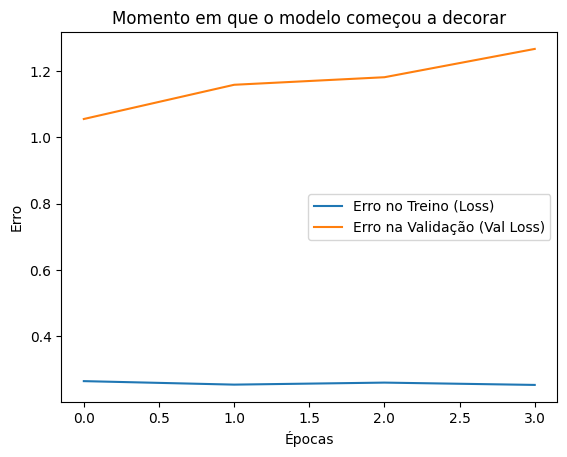

In [129]:
import matplotlib.pyplot as plt

plt.plot(historico.history['loss'], label='Erro no Treino (Loss)')
plt.plot(historico.history['val_loss'], label='Erro na Validação (Val Loss)')
plt.title('Momento em que o modelo começou a decorar')
plt.xlabel('Épocas')
plt.ylabel('Erro')
plt.legend()
plt.show()